In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
!pip install medmnist -q

import medmnist
from medmnist import PathMNIST

train_dataset = PathMNIST(split='train', download=True)
val_dataset   = PathMNIST(split='val',   download=True)
test_dataset  = PathMNIST(split='test',  download=True)

print(f"Train: {len(train_dataset)}")
print(f"Val:   {len(val_dataset)}")
print(f"Test:  {len(test_dataset)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.1 MB/s eta 0:00:0000:010:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.


100%|██████████| 206M/206M [00:31<00:00, 6.48MB/s] 


Train: 89996
Val:   10004
Test:  7180


In [4]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.10.0+cu128
True
Tesla T4


In [5]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, models
from medmnist import PathMNIST
import warnings
warnings.filterwarnings('ignore')

# ── 固定随机种子函数 ──────────────────────────────────────────
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
SEEDS  = [42, 123, 7]
DATA_FRACTIONS = [0.1, 0.2, 0.5, 1.0]
NUM_CLASSES = 9

print(f"Device: {DEVICE}")
print("Setup complete.")

Device: cuda
Setup complete.


In [6]:
# ── Transform ─────────────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5])
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5])
])

# ── 加载完整数据集 ─────────────────────────────────────────────
full_train = PathMNIST(split='train', transform=train_transform, download=False)
val_dataset  = PathMNIST(split='val',   transform=test_transform,  download=False)
test_dataset = PathMNIST(split='test',  transform=test_transform,  download=False)

# ── 按比例 + 按类别分层采样 ────────────────────────────────────
def get_subset(dataset, fraction, seed):
    set_seed(seed)
    labels = np.array(dataset.labels).flatten()
    indices = []
    for c in range(NUM_CLASSES):
        cls_idx = np.where(labels == c)[0]
        n = max(1, int(len(cls_idx) * fraction))
        chosen = np.random.choice(cls_idx, n, replace=False)
        indices.extend(chosen.tolist())
    return Subset(dataset, indices)

# ── 验证 ───────────────────────────────────────────────────────
subset_10 = get_subset(full_train, 0.1, seed=42)
print(f"Full train:  {len(full_train)}")
print(f"10% subset:  {len(subset_10)}")
print(f"Val:         {len(val_dataset)}")
print(f"Test:        {len(test_dataset)}")

Full train:  89996
10% subset:  8996
Val:         10004
Test:        7180


In [7]:
def get_classifier():
    model = models.resnet18(weights=None)
    # 输入已经是3通道，不需要改第一层
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(DEVICE)

# ── 训练一个epoch ──────────────────────────────────────────────
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).squeeze().long()
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

# ── 评估 ───────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            labels = labels.squeeze().long()
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    acc  = accuracy_score(all_labels, all_preds)
    f1   = f1_score(all_labels, all_preds, average='macro')
    bacc = balanced_accuracy_score(all_labels, all_preds)
    return acc, f1, bacc, all_preds, all_labels

# ── 完整训练流程 ───────────────────────────────────────────────
def train_model(train_loader, val_loader, epochs=30, patience=5):
    model = get_classifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    best_val_f1 = 0
    best_state  = None
    no_improve  = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)
        val_acc, val_f1, val_bacc, _, _ = evaluate(model, val_loader)
        scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model

print("Classifier defined.")

Classifier defined.


In [8]:
# ── Traditional Augmentation Transform ────────────────────────
trad_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5, .5, .5], std=[.5, .5, .5])
])

# ── MixUp ─────────────────────────────────────────────────────
def mixup_data(images, labels, alpha=0.2):
    lam = np.random.beta(alpha, alpha)
    batch_size = images.size(0)
    index = torch.randperm(batch_size).to(DEVICE)
    mixed_images = lam * images + (1 - lam) * images[index]
    labels_a, labels_b = labels, labels[index]
    return mixed_images, labels_a, labels_b, lam

def mixup_criterion(criterion, outputs, labels_a, labels_b, lam):
    return lam * criterion(outputs, labels_a) + (1 - lam) * criterion(outputs, labels_b)

def train_epoch_mixup(model, loader, optimizer, criterion, alpha=0.2):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE).squeeze().long()
        images, labels_a, labels_b, lam = mixup_data(images, labels, alpha)
        optimizer.zero_grad()
        outputs = model(images)
        loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (lam * (preds == labels_a).float() + 
                   (1 - lam) * (preds == labels_b).float()).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total

def train_model_mixup(train_loader, val_loader, epochs=30, patience=5, alpha=0.2):
    model = get_classifier()
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)

    best_val_f1 = 0
    best_state  = None
    no_improve  = 0

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch_mixup(model, train_loader, optimizer, criterion, alpha)
        val_acc, val_f1, val_bacc, _, _ = evaluate(model, val_loader)
        scheduler.step()

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state  = {k: v.clone() for k, v in model.state_dict().items()}
            no_improve  = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    model.load_state_dict(best_state)
    return model

print("Augmentation strategies defined.")

Augmentation strategies defined.


In [9]:
# ── Generator ─────────────────────────────────────────────────
class Generator(nn.Module):
    def __init__(self, latent_dim=100, num_classes=9, img_channels=3):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.init_size = 7
        self.fc = nn.Linear(latent_dim + num_classes, 128 * self.init_size ** 2)
        self.conv = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),                        # 7 → 14
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Upsample(scale_factor=2),                        # 14 → 28
            nn.Conv2d(128, 64, 3, padding=1),  nn.BatchNorm2d(64),  nn.LeakyReLU(0.2),
            nn.Conv2d(64, img_channels, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        emb = self.label_emb(labels)
        x   = torch.cat([z, emb], dim=1)
        x   = self.fc(x).view(x.size(0), 128, self.init_size, self.init_size)
        return self.conv(x)

# ── Discriminator ─────────────────────────────────────────────
class Discriminator(nn.Module):
    def __init__(self, num_classes=9, img_channels=3):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, num_classes)
        self.fc_label  = nn.Linear(num_classes, 28 * 28)
        self.conv = nn.Sequential(
            nn.Conv2d(img_channels + 1, 64, 4, 2, 1),  nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 4, 2, 1), nn.BatchNorm2d(128), nn.LeakyReLU(0.2),
            nn.Conv2d(128, 256, 4, 2, 1), nn.BatchNorm2d(256), nn.LeakyReLU(0.2),
        )
        self.fc_out = nn.Linear(256 * 3 * 3, 1)

    def forward(self, img, labels):
        emb = self.label_emb(labels)
        emb = self.fc_label(emb).view(emb.size(0), 1, 28, 28)
        x   = torch.cat([img, emb], dim=1)
        x   = self.conv(x).view(x.size(0), -1)
        return self.fc_out(x)

# ── 训练cGAN ──────────────────────────────────────────────────
def train_cgan(train_subset, epochs=50, batch_size=128, latent_dim=100):
    loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True,
                        num_workers=2, pin_memory=True)

    G = Generator(latent_dim).to(DEVICE)
    D = Discriminator().to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

    for epoch in range(epochs):
        g_losses, d_losses = [], []
        for imgs, labels in loader:
            imgs   = imgs.to(DEVICE)
            labels = labels.to(DEVICE).squeeze().long()
            bs     = imgs.size(0)
            real_t = torch.ones(bs, 1).to(DEVICE)
            fake_t = torch.zeros(bs, 1).to(DEVICE)

            # Train D
            z        = torch.randn(bs, latent_dim).to(DEVICE)
            fake_imgs = G(z, labels)
            d_real   = D(imgs, labels)
            d_fake   = D(fake_imgs.detach(), labels)
            d_loss   = criterion(d_real, real_t) + criterion(d_fake, fake_t)
            opt_D.zero_grad(); d_loss.backward(); opt_D.step()

            # Train G
            z         = torch.randn(bs, latent_dim).to(DEVICE)
            fake_imgs = G(z, labels)
            g_loss    = criterion(D(fake_imgs, labels), real_t)
            opt_G.zero_grad(); g_loss.backward(); opt_G.step()

            g_losses.append(g_loss.item())
            d_losses.append(d_loss.item())

        if (epoch + 1) % 10 == 0:
            print(f"  Epoch [{epoch+1}/{epochs}] "
                  f"G: {np.mean(g_losses):.4f}  D: {np.mean(d_losses):.4f}")

    return G

# ── 生成synthetic images ───────────────────────────────────────
def generate_synthetic(G, n_per_class=100, latent_dim=100):
    G.eval()
    images, labels = [], []
    with torch.no_grad():
        for c in range(NUM_CLASSES):
            z   = torch.randn(n_per_class, latent_dim).to(DEVICE)
            lbl = torch.full((n_per_class,), c, dtype=torch.long).to(DEVICE)
            imgs = G(z, lbl).cpu()
            images.append(imgs)
            labels.extend([c] * n_per_class)
    images = torch.cat(images, dim=0)
    labels = torch.tensor(labels)
    return images, labels

print("cGAN defined.")

cGAN defined.


In [10]:
from torch.utils.data import Dataset, ConcatDataset

# ── Synthetic Dataset包装器 ────────────────────────────────────
class SyntheticDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        # 统一成 numpy array [N, 1] 与PathMNIST一致
        self.labels = labels.numpy().reshape(-1, 1).astype(np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx]

# ── 按ratio生成并合并 ──────────────────────────────────────────
def make_gan_loader(real_subset, G, ratio, batch_size=128, latent_dim=100):
    n_real      = len(real_subset)
    n_per_class = max(1, int(n_real / NUM_CLASSES * ratio))
    print(f"  Generating {n_per_class} synthetic images per class "
          f"({n_per_class * NUM_CLASSES} total)...")

    syn_images, syn_labels = generate_synthetic(G, n_per_class, latent_dim)
    syn_dataset = SyntheticDataset(syn_images, syn_labels)
    combined    = ConcatDataset([real_subset, syn_dataset])

    return DataLoader(combined, batch_size=batch_size, shuffle=True,
                      num_workers=2, pin_memory=True)

# ── 普通loader ─────────────────────────────────────────────────
def make_real_loader(subset, batch_size=128, augment=False):
    if augment:
        full = PathMNIST(split='train', transform=trad_transform, download=False)
        indices = subset.indices
        aug_subset = Subset(full, indices)
        return DataLoader(aug_subset, batch_size=batch_size, shuffle=True,
                          num_workers=2, pin_memory=True)
    return DataLoader(subset, batch_size=batch_size, shuffle=True,
                      num_workers=2, pin_memory=True)

val_loader  = DataLoader(val_dataset,  batch_size=256, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

print("Dataset utilities defined.")

Dataset utilities defined.


In [11]:
import pandas as pd

results = []

for fraction in DATA_FRACTIONS:
    print(f"\n{'='*60}")
    print(f"Data fraction: {fraction*100:.0f}%")
    print(f"{'='*60}")

    print("Training cGAN...")
    set_seed(42)
    train_subset_for_gan = get_subset(full_train, fraction, seed=42)
    G = train_cgan(train_subset_for_gan, epochs=50)
    print("cGAN training complete.")

    for seed in SEEDS:
        print(f"\n  Seed: {seed}")
        set_seed(seed)
        real_subset = get_subset(full_train, fraction, seed=seed)

        strategies = {
            'Real Only':       lambda s: make_real_loader(s),
            'Traditional Aug': lambda s: make_real_loader(s, augment=True),
            'MixUp':           lambda s: make_real_loader(s),
            'cGAN Aug':        lambda s: make_gan_loader(s, G, ratio=0.1),
        }

        for strategy_name, loader_fn in strategies.items():
            print(f"    Strategy: {strategy_name}")
            train_loader = loader_fn(real_subset)

            if strategy_name == 'MixUp':
                model = train_model_mixup(train_loader, val_loader)
            else:
                model = train_model(train_loader, val_loader)

            acc, f1, bacc, preds, labels_true = evaluate(model, test_loader)
            print(f"      Acc={acc:.4f}  F1={f1:.4f}  BAcc={bacc:.4f}")

            results.append({
                'fraction':     fraction,
                'seed':         seed,
                'strategy':     strategy_name,
                'accuracy':     acc,
                'macro_f1':     f1,
                'balanced_acc': bacc,
            })
            # 每跑完一个立即保存
            pd.DataFrame(results).to_csv('/kaggle/working/main_results.csv', index=False)

# ── 全部完成后打印汇总 ─────────────────────────────────────────
df_results = pd.DataFrame(results)
print("\nMain experiment complete. Results saved.")
print(df_results.groupby(['fraction', 'strategy'])[['accuracy','macro_f1','balanced_acc']].mean().round(4))


Data fraction: 10%
Training cGAN...
  Epoch [10/50] G: 1.5818  D: 0.7385
  Epoch [20/50] G: 1.3844  D: 0.9232
  Epoch [30/50] G: 1.3648  D: 1.0129
  Epoch [40/50] G: 1.6507  D: 0.8534
  Epoch [50/50] G: 2.1472  D: 0.6512
cGAN training complete.

  Seed: 42
    Strategy: Real Only
  Early stopping at epoch 19
      Acc=0.7585  F1=0.7114  BAcc=0.7252
    Strategy: Traditional Aug
      Acc=0.7815  F1=0.7305  BAcc=0.7416
    Strategy: MixUp
  Early stopping at epoch 9
      Acc=0.5912  F1=0.5617  BAcc=0.5855
    Strategy: cGAN Aug
  Generating 99 synthetic images per class (891 total)...
  Early stopping at epoch 10
      Acc=0.6428  F1=0.5639  BAcc=0.5841

  Seed: 123
    Strategy: Real Only
  Early stopping at epoch 17
      Acc=0.7747  F1=0.7161  BAcc=0.7324
    Strategy: Traditional Aug
      Acc=0.7816  F1=0.7299  BAcc=0.7450
    Strategy: MixUp
  Early stopping at epoch 16
      Acc=0.7411  F1=0.6950  BAcc=0.7121
    Strategy: cGAN Aug
  Generating 99 synthetic images per class (89

In [12]:
# ── 消融实验：Synthetic-to-Real Ratio（仅10%设定）─────────────
print("Running ablation study (10% setting, varying synthetic ratio)...")

# 复用10%的GAN（重新训练，seed=42）
set_seed(42)
train_subset_for_gan_10 = get_subset(full_train, 0.1, seed=42)
G_ablation = train_cgan(train_subset_for_gan_10, epochs=50)
print("cGAN ready.")

ablation_results = []
RATIOS = [0.05, 0.1, 0.2]

for ratio in RATIOS:
    print(f"\n  Synthetic ratio: {ratio*100:.0f}%")
    for seed in SEEDS:
        set_seed(seed)
        real_subset = get_subset(full_train, 0.1, seed=seed)
        train_loader = make_gan_loader(real_subset, G_ablation, ratio=ratio)
        model = train_model(train_loader, val_loader)
        acc, f1, bacc, _, _ = evaluate(model, test_loader)
        print(f"    Seed={seed}  Acc={acc:.4f}  F1={f1:.4f}  BAcc={bacc:.4f}")

        ablation_results.append({
            'ratio':        ratio,
            'seed':         seed,
            'accuracy':     acc,
            'macro_f1':     f1,
            'balanced_acc': bacc,
        })
        pd.DataFrame(ablation_results).to_csv('/kaggle/working/ablation_results.csv', index=False)

df_ablation = pd.DataFrame(ablation_results)
print("\nAblation complete.")
print(df_ablation.groupby('ratio')[['accuracy','macro_f1','balanced_acc']].agg(['mean','std']).round(4))

Running ablation study (10% setting, varying synthetic ratio)...
  Epoch [10/50] G: 1.5818  D: 0.7385
  Epoch [20/50] G: 1.3844  D: 0.9232
  Epoch [30/50] G: 1.3648  D: 1.0129
  Epoch [40/50] G: 1.6507  D: 0.8534
  Epoch [50/50] G: 2.1472  D: 0.6512
cGAN ready.

  Synthetic ratio: 5%
  Generating 49 synthetic images per class (441 total)...
  Early stopping at epoch 9
    Seed=42  Acc=0.7489  F1=0.6738  BAcc=0.6699
  Generating 49 synthetic images per class (441 total)...
  Early stopping at epoch 10
    Seed=123  Acc=0.7233  F1=0.6631  BAcc=0.6612
  Generating 49 synthetic images per class (441 total)...
  Early stopping at epoch 8
    Seed=7  Acc=0.7181  F1=0.6522  BAcc=0.6628

  Synthetic ratio: 10%
  Generating 99 synthetic images per class (891 total)...
  Early stopping at epoch 17
    Seed=42  Acc=0.7451  F1=0.6884  BAcc=0.6914
  Generating 99 synthetic images per class (891 total)...
  Early stopping at epoch 19
    Seed=123  Acc=0.7500  F1=0.6994  BAcc=0.7115
  Generating 99 s

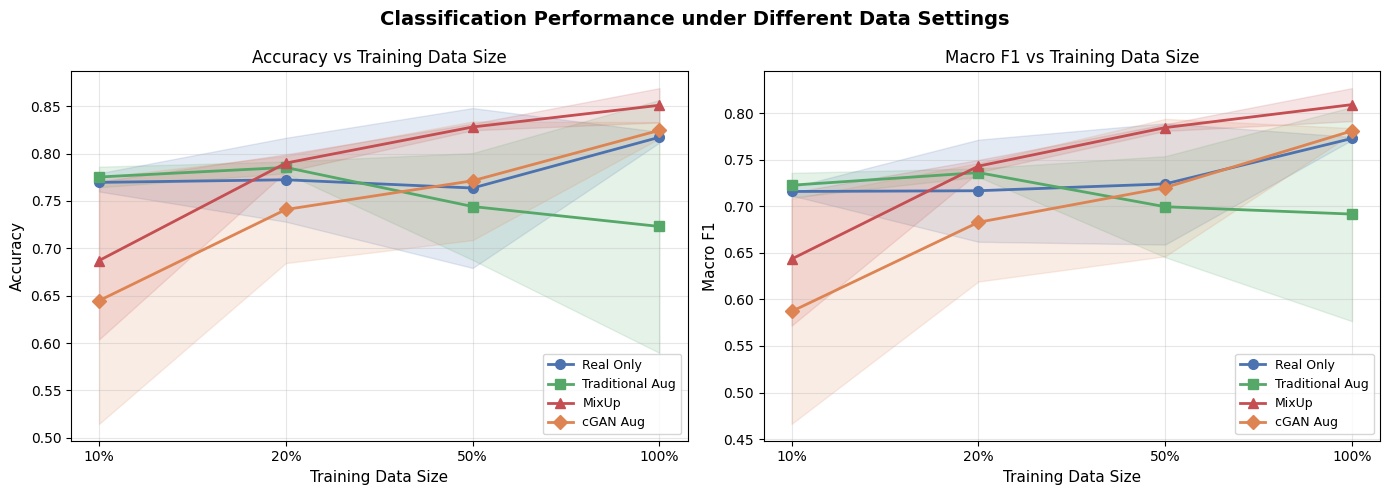

Main plot saved.


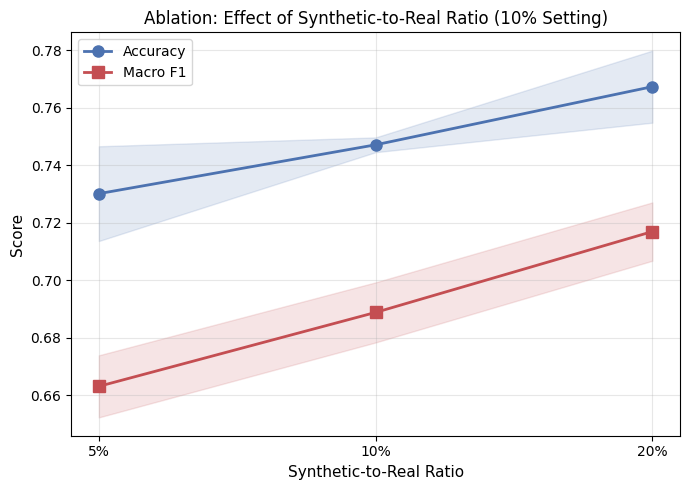

Ablation plot saved.


In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── 数据准备 ───────────────────────────────────────────────────
summary = df_main.groupby(['fraction','strategy'])[['accuracy','macro_f1']].agg(['mean','std']).reset_index()
summary.columns = ['fraction','strategy','acc_mean','acc_std','f1_mean','f1_std']

fractions = [0.1, 0.2, 0.5, 1.0]
x_labels  = ['10%', '20%', '50%', '100%']
strategies = ['Real Only', 'Traditional Aug', 'MixUp', 'cGAN Aug']
colors     = ['#4C72B0', '#55A868', '#C44E52', '#DD8452']
markers    = ['o', 's', '^', 'D']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Classification Performance under Different Data Settings', fontsize=14, fontweight='bold')

for ax, metric, metric_std, ylabel in zip(
    axes,
    ['acc_mean', 'f1_mean'],
    ['acc_std',  'f1_std'],
    ['Accuracy', 'Macro F1']
):
    for strat, color, marker in zip(strategies, colors, markers):
        sub = summary[summary['strategy'] == strat].sort_values('fraction')
        ax.plot(x_labels, sub[metric].values, marker=marker,
                label=strat, color=color, linewidth=2, markersize=7)
        ax.fill_between(
            x_labels,
            sub[metric].values - sub[metric_std].values,
            sub[metric].values + sub[metric_std].values,
            alpha=0.15, color=color
        )
    ax.set_xlabel('Training Data Size', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel + ' vs Training Data Size', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig('/kaggle/working/main_results_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Main plot saved.")

# ── 消融实验图 ─────────────────────────────────────────────────
abl_summary = df_ablation.groupby('ratio')[['accuracy','macro_f1']].agg(['mean','std']).reset_index()
abl_summary.columns = ['ratio','acc_mean','acc_std','f1_mean','f1_std']

fig2, ax2 = plt.subplots(figsize=(7, 5))
x_ratio = ['5%', '10%', '20%']

for metric, metric_std, label, color, marker in zip(
    ['acc_mean', 'f1_mean'],
    ['acc_std',  'f1_std'],
    ['Accuracy', 'Macro F1'],
    ['#4C72B0', '#C44E52'],
    ['o', 's']
):
    ax2.plot(x_ratio, abl_summary[metric].values, marker=marker,
             label=label, color=color, linewidth=2, markersize=8)
    ax2.fill_between(
        x_ratio,
        abl_summary[metric].values - abl_summary[metric_std].values,
        abl_summary[metric].values + abl_summary[metric_std].values,
        alpha=0.15, color=color
    )

ax2.set_xlabel('Synthetic-to-Real Ratio', fontsize=11)
ax2.set_ylabel('Score', fontsize=11)
ax2.set_title('Ablation: Effect of Synthetic-to-Real Ratio (10% Setting)', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig('/kaggle/working/ablation_plot.png', dpi=150, bbox_inches='tight')
plt.show()
print("Ablation plot saved.")

Running 10% - Traditional Aug...
  Early stopping at epoch 28
  Done.
Running 20% - MixUp...
  Early stopping at epoch 17
  Done.
Running 50% - MixUp...
  Early stopping at epoch 10
  Done.
Running 100% - MixUp...
  Early stopping at epoch 18
  Done.


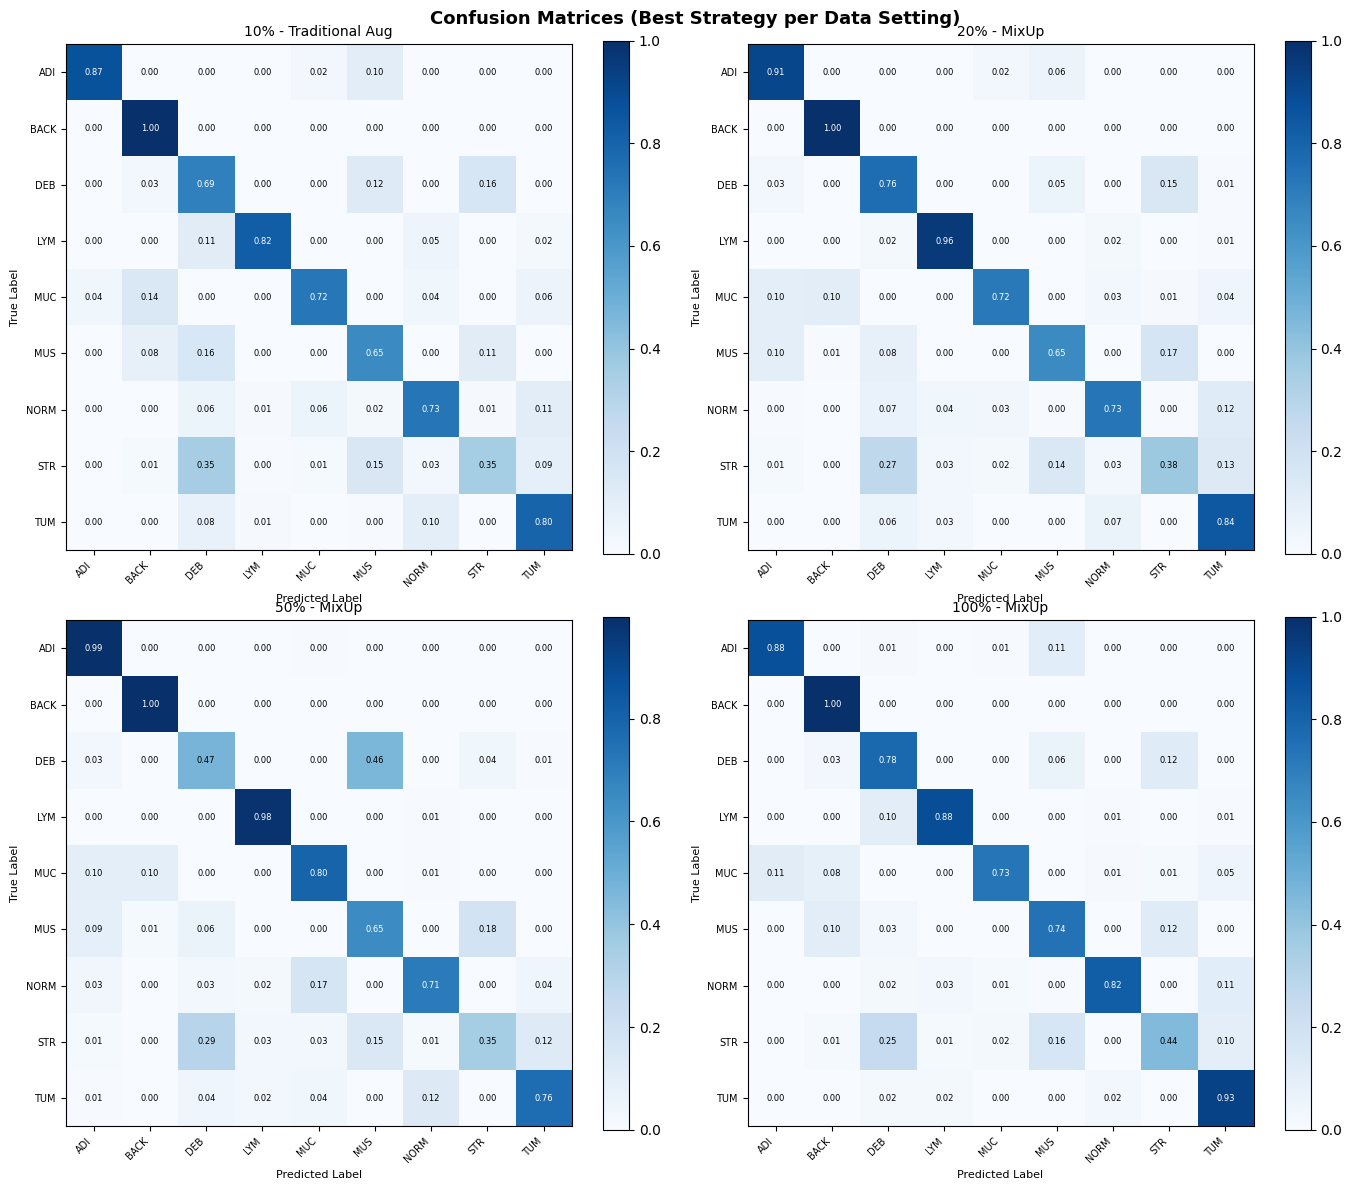

Confusion matrices saved.


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import itertools

CLASS_NAMES = ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']

def plot_confusion_matrix(cm, title, ax):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(title, fontsize=10)
    plt.colorbar(im, ax=ax)
    tick_marks = np.arange(len(CLASS_NAMES))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha='right', fontsize=7)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(CLASS_NAMES, fontsize=7)
    thresh = cm_norm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        ax.text(j, i, f'{cm_norm[i,j]:.2f}',
                ha='center', va='center', fontsize=6,
                color='white' if cm_norm[i,j] > thresh else 'black')
    ax.set_ylabel('True Label', fontsize=8)
    ax.set_xlabel('Predicted Label', fontsize=8)

# 每个数据量下表现最好的strategy（根据主实验mean F1）
best_strategies = {
    0.1: 'Traditional Aug',
    0.2: 'MixUp',
    0.5: 'MixUp',
    1.0: 'MixUp',
}

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Confusion Matrices (Best Strategy per Data Setting)', fontsize=13, fontweight='bold')
axes = axes.flatten()

for idx, (fraction, strategy) in enumerate(best_strategies.items()):
    print(f"Running {fraction*100:.0f}% - {strategy}...")
    set_seed(42)
    real_subset = get_subset(full_train, fraction, seed=42)

    if strategy == 'Traditional Aug':
        train_loader = make_real_loader(real_subset, augment=True)
        model = train_model(train_loader, val_loader)
    elif strategy == 'MixUp':
        train_loader = make_real_loader(real_subset)
        model = train_model_mixup(train_loader, val_loader)

    _, _, _, preds, labels_true = evaluate(model, test_loader)
    cm = confusion_matrix(labels_true, preds)
    plot_confusion_matrix(cm, f'{fraction*100:.0f}% - {strategy}', axes[idx])
    print(f"  Done.")

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrices saved.")